# Modelo Preditivo de NPS

Aqui eu vou tentar construir um modelo que consiga prever se um cliente vai ser um detrator ou nao, usando os dados operacionais que ja existem durante a jornada de compra.

A ideia e simples: se der pra prever isso antes da pesquisa de NPS, a empresa pode agir preventivamente nos casos de maior risco.

Vou testar dois modelos: primeiro uma Regressao Logistica, mais simples, e depois um Random Forest. Ai comparo os dois.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import joblib
import warnings

warnings.filterwarnings('ignore')

## Carregando os dados

Vou usar a base tratada que foi gerada no notebook de EDA.

In [2]:
df = pd.read_csv('../data/processed/nps_tratado.csv')

print(f'Shape: {df.shape}')
df.head()

Shape: (2500, 21)


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,...,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,nps_categoria,faixa_atraso
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,...,55.53,3,0,4,6.9,0,3,6.5,Neutro,1-2 dias
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,...,28.23,3,0,10,2.4,0,3,0.0,Detrator,3-5 dias
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,...,40.99,1,4,5,4.8,0,7,1.5,Detrator,1-2 dias
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,...,35.24,3,1,11,5.9,0,4,0.3,Detrator,1-2 dias
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,...,39.32,1,1,0,6.1,0,3,7.9,Neutro,1-2 dias


## Definindo a variavel alvo

Aqui preciso transformar o problema em classificacao binaria. A logica e:

1 = Detrator (nps_score de 0 a 6)
0 = Nao-Detrator (neutros e promotores, score acima de 6)

Escolhi essa divisao porque o foco da empresa e identificar quem vai falar mal dela, ja que esse grupo tem 0% de recompra em 30 dias.

In [3]:
# criando a coluna target
df['detrator'] = (df['nps_categoria'] == 'Detrator').astype(int)

print('Distribuicao da target:')
print(df['detrator'].value_counts())
print()
print(f'% de detratores: {df["detrator"].mean()*100:.1f}%')

Distribuicao da target:
detrator
1    1851
0     649
Name: count, dtype: int64

% de detratores: 74.0%


## Selecionando as features

Com base na analise de correlacao que fiz no notebook anterior, as variaveis que mais influenciam o NPS sao atraso na entrega, reclamacoes, contatos com atendimento e tempo de resolucao.

Uma consideracao importante: existe a variavel `csat_internal_score`, que tem correlacao alta com o NPS (0,56), mas decidi tirar ela do modelo porque pode ser coletada no mesmo momento que a pesquisa de NPS. Se for esse o caso, usar ela seria leakage. Como nao tenho certeza do timing exato, prefiro ser conservador e nao usar.

Tambem nao vou usar `repeat_purchase_30d` porque so existe depois da jornada de compra, mesmo problema do NPS.

Removi tambem os identificadores `customer_id` e `order_id`, o `nps_score` (origem da target) e as colunas derivadas `nps_categoria` e `faixa_atraso`.

In [4]:
# colunas que vou usar como features
features = [
    'delivery_delay_days',
    'complaints_count',
    'customer_service_contacts',
    'resolution_time_days',
    'delivery_time_days',
    'delivery_attempts',
    'freight_value',
    'order_value',
    'items_quantity',
    'payment_installments',
    'discount_value',
    'customer_age',
    'customer_tenure_months',
    'customer_region'
]

# separando features e target
X = df[features].copy()
y = df['detrator'].copy()

print(f'Features selecionadas: {len(features)}')
print(X.dtypes)

Features selecionadas: 14
delivery_delay_days            int64
complaints_count               int64
customer_service_contacts      int64
resolution_time_days           int64
delivery_time_days             int64
delivery_attempts              int64
freight_value                float64
order_value                  float64
items_quantity                 int64
payment_installments           int64
discount_value               float64
customer_age                   int64
customer_tenure_months         int64
customer_region               object
dtype: object


## Preparando as features

A variavel `customer_region` e texto, entao preciso transformar em numero. Vou usar `pd.get_dummies` que cria uma coluna para cada regiao.

In [5]:
# transformando customer_region em colunas dummies
X = pd.get_dummies(X, columns=['customer_region'], drop_first=True)

print(f'Shape depois do encoding: {X.shape}')
print(f'\nColunas finais:')
for col in X.columns:
    print(f'  {col}')

Shape depois do encoding: (2500, 17)

Colunas finais:
  delivery_delay_days
  complaints_count
  customer_service_contacts
  resolution_time_days
  delivery_time_days
  delivery_attempts
  freight_value
  order_value
  items_quantity
  payment_installments
  discount_value
  customer_age
  customer_tenure_months
  customer_region_Nordeste
  customer_region_Norte
  customer_region_Sudeste
  customer_region_Sul


## Dividindo em treino e teste

Vou usar 80% dos dados para treinar e 20% para testar. O `random_state=42` e pra garantir que os resultados sejam reproduziveis.

Uma coisa que aprendi lendo sobre ML: o ideal em producao seria usar um split temporal, treinando em pedidos antigos e testando em pedidos recentes. Mas como o dataset nao tem data, vou usar o split aleatorio mesmo.

In [6]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino: {X_treino.shape[0]} registros')
print(f'Teste:  {X_teste.shape[0]} registros')
print(f'\n% de detratores no treino: {y_treino.mean()*100:.1f}%')
print(f'% de detratores no teste:  {y_teste.mean()*100:.1f}%')

Treino: 2000 registros
Teste:  500 registros

% de detratores no treino: 74.1%
% de detratores no teste:  74.0%


## Modelo 1: Regressao Logistica

Comeco com a Regressao Logistica porque e o modelo mais simples para classificacao. Serve como baseline.

Como a base esta desbalanceada (muito mais detrator do que nao-detrator), vou usar `class_weight='balanced'`. Isso faz o modelo dar mais peso para a classe minoritaria durante o treino.

In [7]:
modelo_lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
modelo_lr.fit(X_treino, y_treino)

y_pred_lr = modelo_lr.predict(X_teste)

print('=== Regressao Logistica ===')
print(classification_report(y_teste, y_pred_lr, target_names=['Nao-Detrator', 'Detrator']))

=== Regressao Logistica ===


              precision    recall  f1-score   support

Nao-Detrator       0.58      0.80      0.67       130
    Detrator       0.92      0.79      0.85       370

    accuracy                           0.80       500
   macro avg       0.75      0.80      0.76       500
weighted avg       0.83      0.80      0.81       500


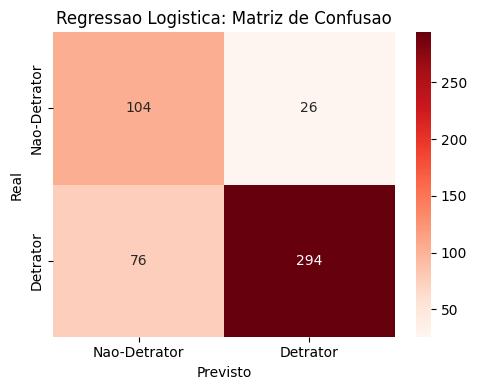

In [8]:
# matriz de confusao da regressao logistica
cm_lr = confusion_matrix(y_teste, y_pred_lr)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Reds', ax=ax,
            xticklabels=['Nao-Detrator', 'Detrator'],
            yticklabels=['Nao-Detrator', 'Detrator'])
ax.set_xlabel('Previsto')
ax.set_ylabel('Real')
ax.set_title('Regressao Logistica: Matriz de Confusao')
plt.tight_layout()
plt.savefig('../reports/fig_09_confusao_lr.png', dpi=120, bbox_inches='tight')
plt.show()

## Modelo 2: Random Forest

Agora vou tentar o Random Forest. Esse modelo cria varias arvores de decisao e combina os resultados. Tambem com class_weight balanceado para lidar com o desbalanceamento.

In [9]:
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
modelo_rf.fit(X_treino, y_treino)

y_pred_rf = modelo_rf.predict(X_teste)

print('=== Random Forest ===')
print(classification_report(y_teste, y_pred_rf, target_names=['Nao-Detrator', 'Detrator']))

=== Random Forest ===
              precision    recall  f1-score   support

Nao-Detrator       0.76      0.50      0.60       130
    Detrator       0.84      0.94      0.89       370

    accuracy                           0.83       500
   macro avg       0.80      0.72      0.75       500
weighted avg       0.82      0.83      0.82       500



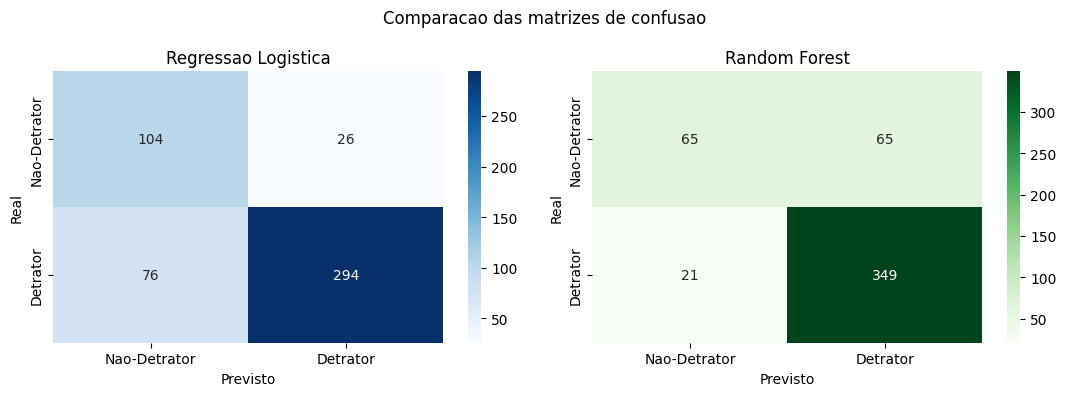

In [10]:
# matriz de confusao do random forest
cm_rf = confusion_matrix(y_teste, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Nao-Detrator', 'Detrator'],
            yticklabels=['Nao-Detrator', 'Detrator'])
axes[0].set_title('Regressao Logistica')
axes[0].set_xlabel('Previsto')
axes[0].set_ylabel('Real')

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Nao-Detrator', 'Detrator'],
            yticklabels=['Nao-Detrator', 'Detrator'])
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Previsto')
axes[1].set_ylabel('Real')

plt.suptitle('Comparacao das matrizes de confusao', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/fig_10_confusao_comparacao.png', dpi=120, bbox_inches='tight')
plt.show()

## Comparando os modelos com a curva ROC

A curva ROC mostra o quanto cada modelo consegue separar detratores de nao-detratores. Quanto maior a area embaixo da curva (AUC), melhor.

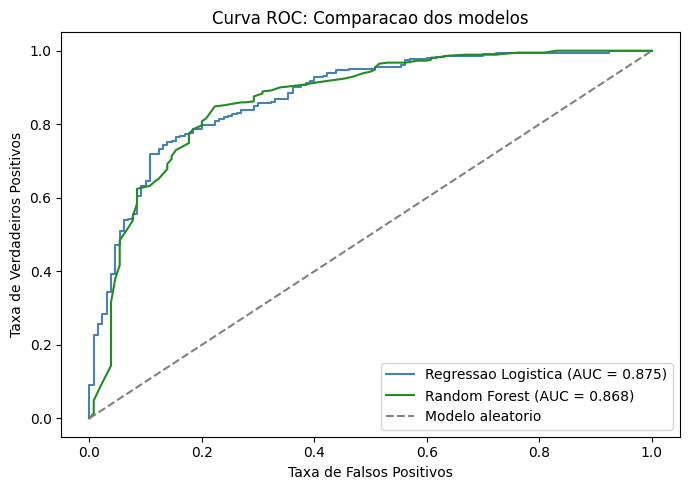

AUC Regressao Logistica: 0.875
AUC Random Forest:       0.868


In [11]:
# probabilidades para o calculo do ROC
prob_lr = modelo_lr.predict_proba(X_teste)[:, 1]
prob_rf = modelo_rf.predict_proba(X_teste)[:, 1]

auc_lr = roc_auc_score(y_teste, prob_lr)
auc_rf = roc_auc_score(y_teste, prob_rf)

fpr_lr, tpr_lr, _ = roc_curve(y_teste, prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_teste, prob_rf)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_lr, tpr_lr, label=f'Regressao Logistica (AUC = {auc_lr:.3f})', color='steelblue')
ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', color='forestgreen')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Modelo aleatorio')
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.set_title('Curva ROC: Comparacao dos modelos')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/fig_11_roc_comparacao.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'AUC Regressao Logistica: {auc_lr:.3f}')
print(f'AUC Random Forest:       {auc_rf:.3f}')

## Importancia das features no Random Forest

Uma das coisas legais do Random Forest e que ele mostra quais features foram mais importantes para fazer as previsoes. Vou conferir se bate com o que a EDA mostrou.

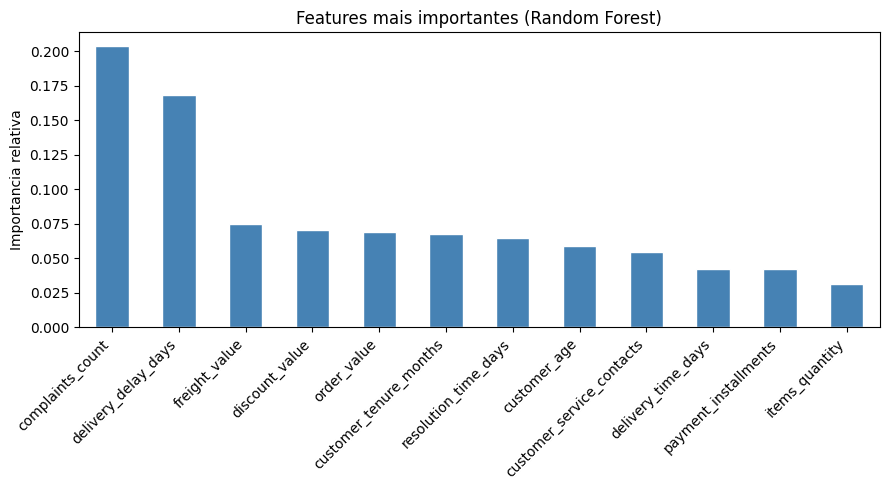

In [12]:
importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X_treino.columns
).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(9, 5))
importancias.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Features mais importantes (Random Forest)')
ax.set_ylabel('Importancia relativa')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/fig_12_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## Salvando o modelo

Vou salvar o modelo com melhor desempenho na pratica para o cenario do negocio. Como o objetivo e identificar detratores, prefiro escolher pelo recall da classe Detrator e tambem pelo AUC.

In [13]:
# Escolho o modelo com melhor AUC para salvar
if auc_rf >= auc_lr:
    modelo_final = modelo_rf
    nome_modelo = 'Random Forest'
else:
    modelo_final = modelo_lr
    nome_modelo = 'Regressao Logistica'

print(f'Modelo escolhido: {nome_modelo}')

joblib.dump(modelo_final, '../models/modelo_nps.pkl')
print('Modelo salvo em models/modelo_nps.pkl')

# so pra confirmar que consegue carregar de volta
modelo_carregado = joblib.load('../models/modelo_nps.pkl')
print('Carregamento confirmado.')

Modelo escolhido: Regressao Logistica
Modelo salvo em models/modelo_nps.pkl
Carregamento confirmado.


## Como a empresa usaria esse modelo na pratica

O modelo nao e o produto final, e uma ferramenta para a equipe de operacoes agir mais rapido.

Cenario de uso:

1. A cada pedido que se aproxima do prazo de entrega ou que ja tem algum sinal de problema (atraso, reclamacao aberta, multiplos contatos com atendimento), o sistema alimenta o modelo com os dados operacionais daquele pedido.

2. O modelo retorna uma probabilidade: "esse cliente tem X% de chance de virar detrator."

3. Pedidos com probabilidade acima de um limiar definido pelo negocio entram numa fila de atencao prioritaria.

4. A equipe de atendimento entra em contato proativamente antes da pesquisa de NPS ser enviada.

Por que funciona:

O modelo aprendeu que delivery_delay_days, complaints_count e customer_service_contacts sao os fatores que mais separam detratores de nao-detratores, exatamente o que a analise exploratoria ja tinha indicado. A vantagem e que agora isso vira um numero unico que pode ser monitorado e atuado em escala.

Limitacao importante:

A base esta bastante desbalanceada (74% detratores), o que ajuda o modelo a acertar muito na classe majoritaria mas tem mais dificuldade em identificar corretamente os nao-detratores. O uso de `class_weight='balanced'` ajuda, mas em producao seria importante coletar mais dados de clientes satisfeitos ou aplicar tecnicas como SMOTE para balancear a base.